# F1 Lap Time Prediction Per Driver
This notebook predicts lap times for each driver individually, ensuring that their performance is not mixed together. This gives a clearer picture of each driver's specific degradation and pace over the stint.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")

In [ ]:
# Load all Spain laps
files = glob.glob('datasets/Spain/*_Laps.csv')
df_list = []
driver_sets = []

for f in files:
    temp_df = pd.read_csv(f)
    # Extract Year and Race from filename as basic info
    race_info = f.split('/')[-1].split('\\')[-1].replace('_Laps.csv', '')
    temp_df['Event'] = race_info
    df_list.append(temp_df)
    # Collect unique drivers for this event
    driver_sets.append(set(temp_df['Driver'].dropna().unique()))

# Find drivers that are present in ALL datasets
common_drivers = set.intersection(*driver_sets) if driver_sets else set()
print(f"Drivers present in all datasets: {common_drivers}")

df = pd.concat(df_list, ignore_index=True)

# Filter to only keep common drivers
df = df[df['Driver'].isin(common_drivers)]

print(f"Loaded {len(df)} total laps from {len(files)} files for common drivers.")
df.head()

Drivers present in all datasets: {'TSU', 'ALO', 'LEC', 'GAS', 'OCO', 'VER', 'NOR', 'RUS', 'SAI', 'HAM', 'ALB'}
Loaded 2816 total laps from 4 files for common drivers.


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,Event
0,0 days 01:03:42.883000,VER,1,0 days 00:01:29.739000,1.0,1.0,NaN,NaN,NaN,0 days 00:00:32.819000,...,Red Bull Racing,0 days 01:02:12.915000,2022-05-22 13:03:12.928,12,2.0,False,NaN,False,False,2022_Spain
1,0 days 01:05:10.392000,VER,1,0 days 00:01:27.509000,2.0,1.0,NaN,NaN,0 days 00:00:24.345000,0 days 00:00:33.238000,...,Red Bull Racing,0 days 01:03:42.883000,2022-05-22 13:04:42.896,1,2.0,False,NaN,False,True,2022_Spain
2,0 days 01:06:37.966000,VER,1,0 days 00:01:27.574000,3.0,1.0,NaN,NaN,0 days 00:00:24.494000,0 days 00:00:33.214000,...,Red Bull Racing,0 days 01:05:10.392000,2022-05-22 13:06:10.405,1,2.0,False,NaN,False,True,2022_Spain
3,0 days 01:08:05.567000,VER,1,0 days 00:01:27.601000,4.0,1.0,NaN,NaN,0 days 00:00:24.462000,0 days 00:00:33.042000,...,Red Bull Racing,0 days 01:06:37.966000,2022-05-22 13:07:37.979,1,2.0,False,NaN,False,True,2022_Spain
4,0 days 01:09:33.504000,VER,1,0 days 00:01:27.937000,5.0,1.0,NaN,NaN,0 days 00:00:24.486000,0 days 00:00:33.222000,...,Red Bull Racing,0 days 01:08:05.567000,2022-05-22 13:09:05.580,1,2.0,False,NaN,False,True,2022_Spain


### Preprocessing
- Convert Timedelta strings (like `0 days 00:01:29.739000`) to seconds.
- Drop invalid/missing laps and out-laps (lap time is usually NaN or very high).

In [3]:
def timedelta_to_seconds(td_str):
    if pd.isna(td_str):
        return np.nan
    try:
        # Format is '0 days 00:01:29.739000'
        parts = str(td_str).split(' ')
        time_part = parts[-1]
        h, m, s = time_part.split(':')
        return int(h) * 3600 + int(m) * 60 + float(s)
    except:
        return np.nan

df['LapTime_sec'] = df['LapTime'].apply(timedelta_to_seconds)
df = df.dropna(subset=['LapTime_sec', 'Driver', 'Compound', 'TyreLife', 'LapNumber'])

# Remove pit out laps (laps where driver exits the pit)
df = df[df['PitOutTime'].isna()]

# Remove pit in laps (laps where driver enters the pit - artificially slow)
df = df[df['PitInTime'].isna()]

# Filter out excessively slow laps (e.g. out laps, VSC, Safety Car)
# Assuming a normal lap is < 120 seconds for most tracks, but let's use a dynamic threshold per driver/event or fixed for simplicity
# We'll use 150 seconds as a global loose upper bound for normal racing laps
df = df[df['LapTime_sec'] < 150]

df.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,Event,LapTime_sec
0,0 days 01:03:42.883000,VER,1,0 days 00:01:29.739000,1.0,1.0,NaN,NaN,NaN,0 days 00:00:32.819000,...,0 days 01:02:12.915000,2022-05-22 13:03:12.928,12,2.0,False,NaN,False,False,2022_Spain,89.739
1,0 days 01:05:10.392000,VER,1,0 days 00:01:27.509000,2.0,1.0,NaN,NaN,0 days 00:00:24.345000,0 days 00:00:33.238000,...,0 days 01:03:42.883000,2022-05-22 13:04:42.896,1,2.0,False,NaN,False,True,2022_Spain,87.509
2,0 days 01:06:37.966000,VER,1,0 days 00:01:27.574000,3.0,1.0,NaN,NaN,0 days 00:00:24.494000,0 days 00:00:33.214000,...,0 days 01:05:10.392000,2022-05-22 13:06:10.405,1,2.0,False,NaN,False,True,2022_Spain,87.574
3,0 days 01:08:05.567000,VER,1,0 days 00:01:27.601000,4.0,1.0,NaN,NaN,0 days 00:00:24.462000,0 days 00:00:33.042000,...,0 days 01:06:37.966000,2022-05-22 13:07:37.979,1,2.0,False,NaN,False,True,2022_Spain,87.601
4,0 days 01:09:33.504000,VER,1,0 days 00:01:27.937000,5.0,1.0,NaN,NaN,0 days 00:00:24.486000,0 days 00:00:33.222000,...,0 days 01:08:05.567000,2022-05-22 13:09:05.580,1,2.0,False,NaN,False,True,2022_Spain,87.937


### Feature Engineering
We want to train a model for each driver, predicting `LapTime_sec` using:
- `LapNumber`: Account for fuel burn (car gets lighter and faster)
- `TyreLife`: Account for tyre degradation (car gets slower)
- `Compound`: The tyre compound used
- `Stint`: The stint number
- `Event`: The race track (if using multiple tracks)

In [4]:
features = ['LapNumber', 'TyreLife', 'Compound', 'Stint', 'Event']
target = 'LapTime_sec'

# Encode categorical features
le_compound = LabelEncoder()
df['Compound'] = le_compound.fit_transform(df['Compound'])

le_event = LabelEncoder()
df['Event'] = le_event.fit_transform(df['Event'])

print("Compounds mapped:", dict(zip(le_compound.classes_, le_compound.transform(le_compound.classes_))))


Compounds mapped: {'HARD': 0, 'MEDIUM': 1, 'SOFT': 2}


### Model Training per Driver
Here, we split the dataset by driver. We'll train a separate RandomForestRegressor for each driver and evaluate it.

In [5]:
drivers = df['Driver'].unique()
models = {}
scores = []

for driver in drivers:
    df_driver = df[df['Driver'] == driver]
    
    if len(df_driver) < 10:
        print(f"Skipping {driver}, not enough laps.")
        continue

    X = df_driver[features]
    y = df_driver[target]
    
    # Train-test split (80-20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train Model
    model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
    model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    models[driver] = model
    scores.append({'Driver': driver, 'Laps': len(df_driver), 'MAE': mae, 'RMSE': rmse})

scores_df = pd.DataFrame(scores)
print("\nModel Performance per Driver:")
display(scores_df.sort_values('MAE').reset_index(drop=True))



Model Performance per Driver:


,Driver,Laps,MAE,RMSE
0,RUS,244,0.318770,0.749544
1,LEC,207,0.374083,0.737602
2,HAM,244,0.444173,0.604900
3,TSU,237,0.470676,0.771758
4,NOR,241,0.492555,0.864686
5,OCO,246,0.699275,1.401267
6,VER,242,0.737838,1.683615
7,ALB,200,0.815050,2.171933
8,GAS,243,0.842385,2.391684
9,SAI,244,1.054804,3.270159


### Visualization: Actual vs Predicted Lap Times for Each Driver
Let's visualize how our driver-specific models perform over a full race for each driver (we'll plot the first 5 drivers to avoid too many plots).

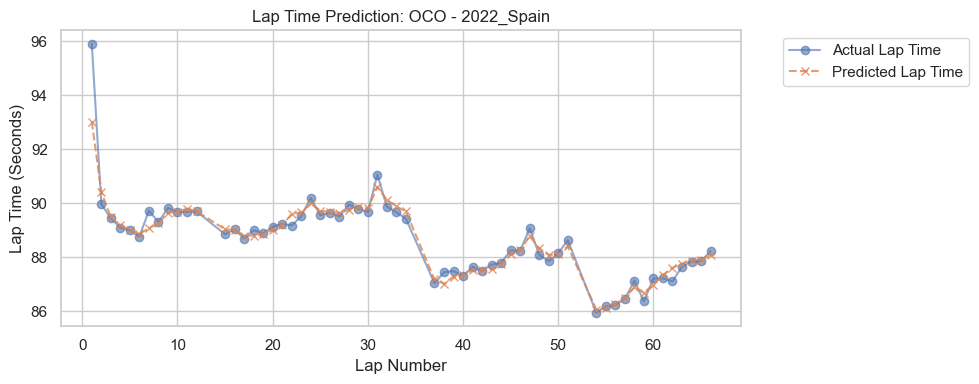

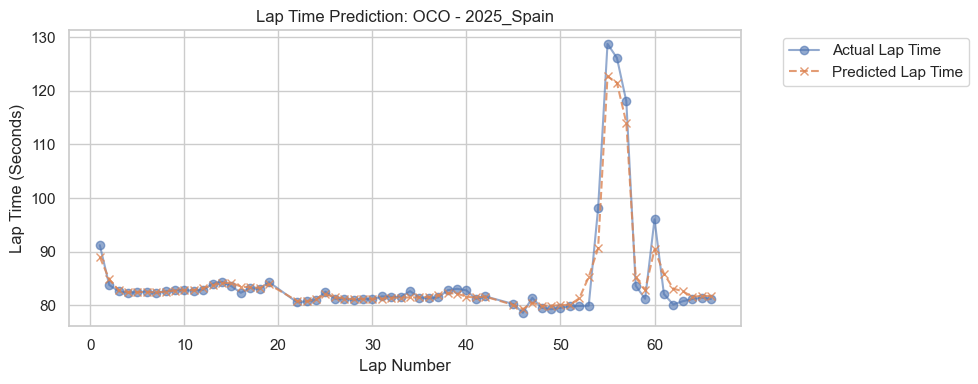

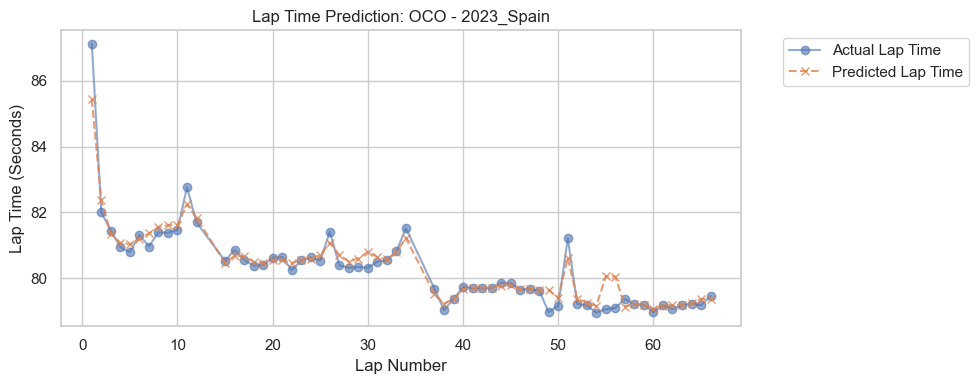

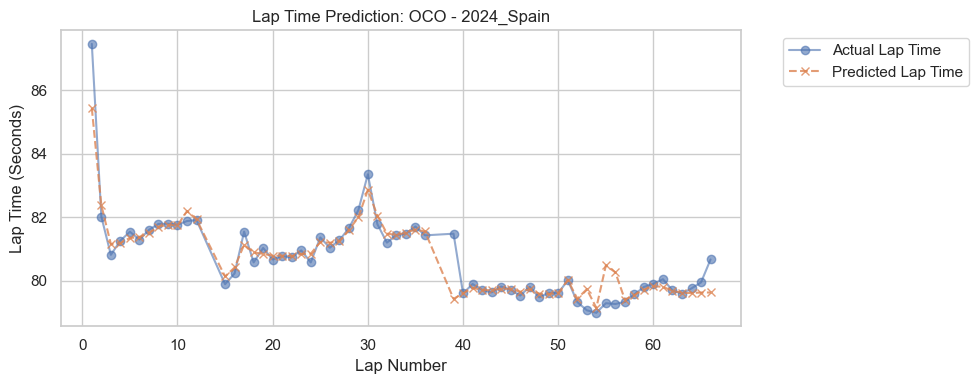

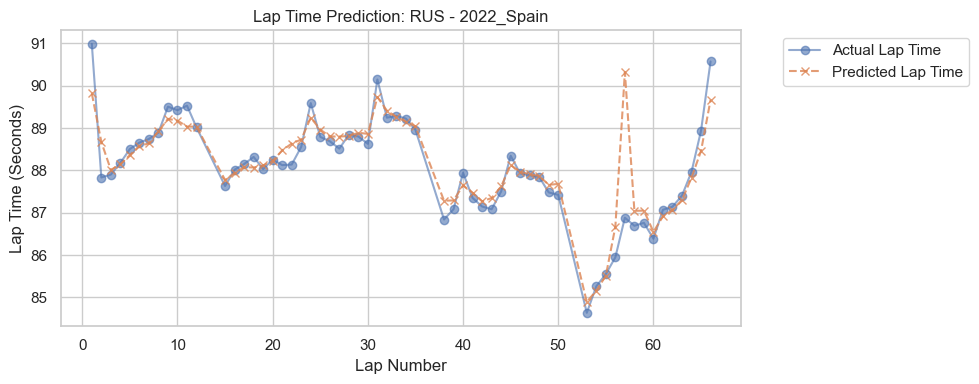

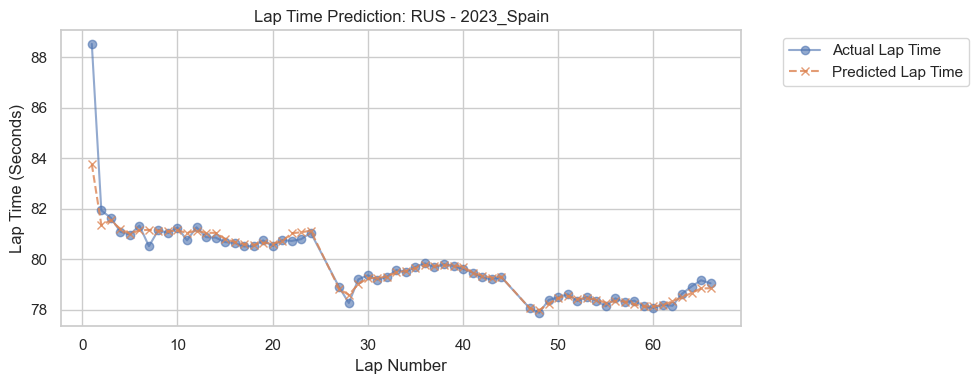

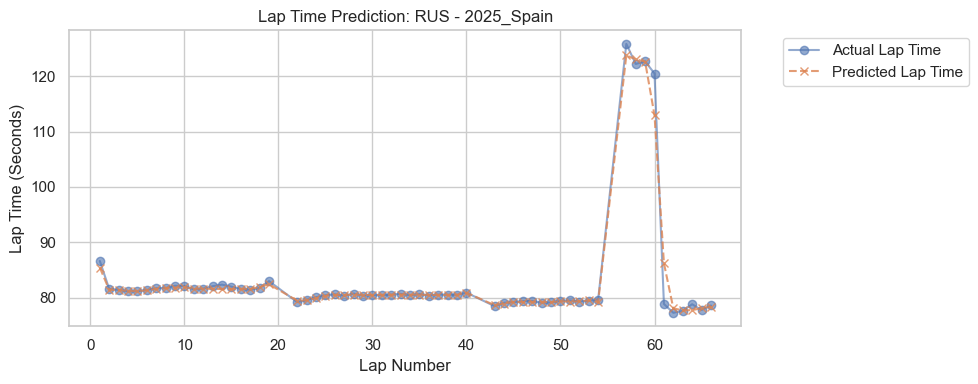

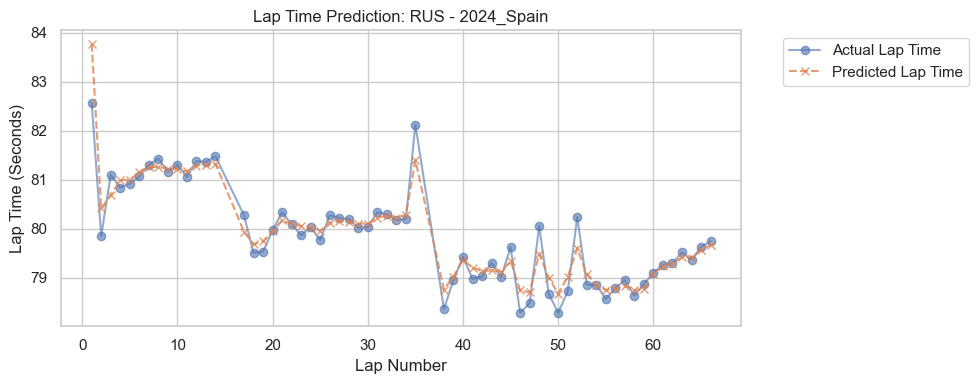

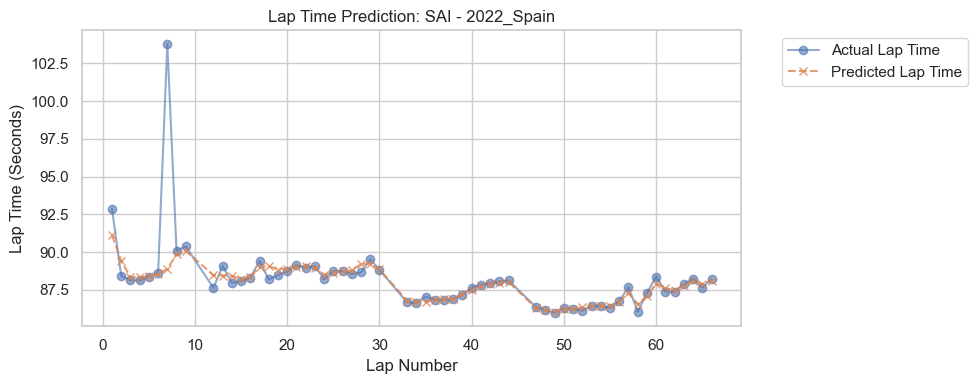

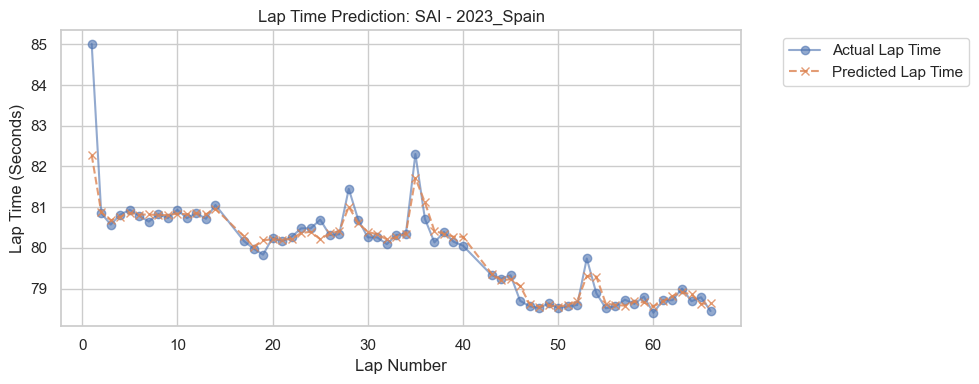

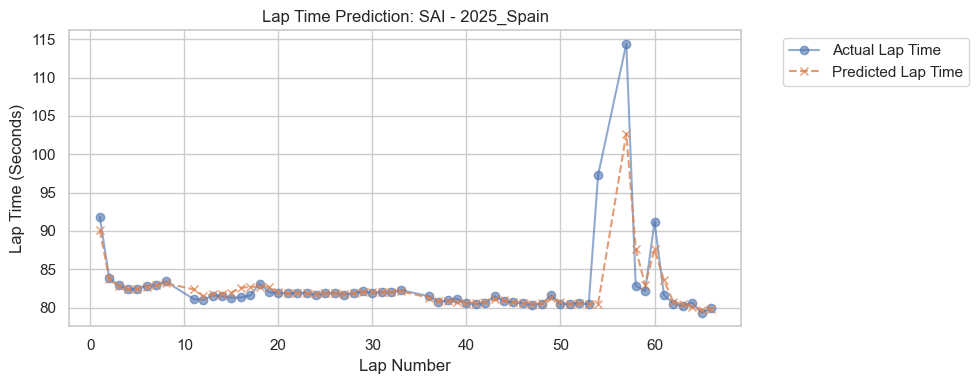

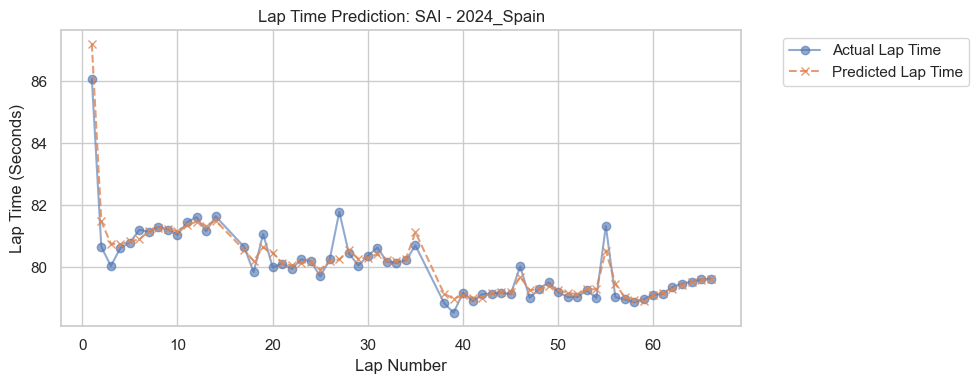

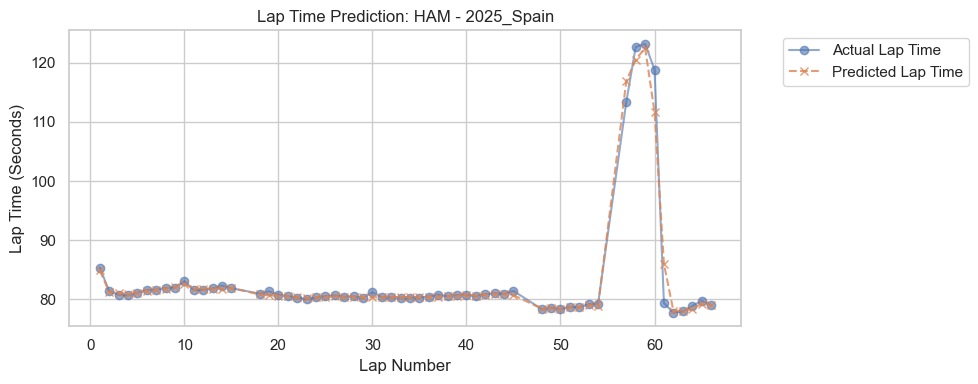

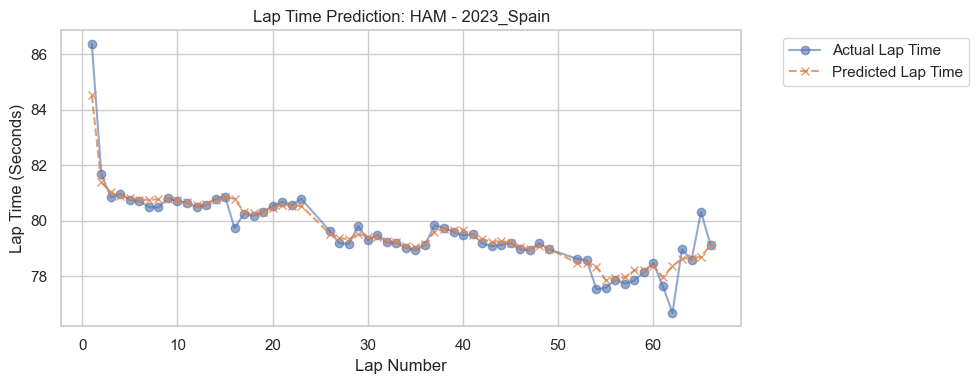

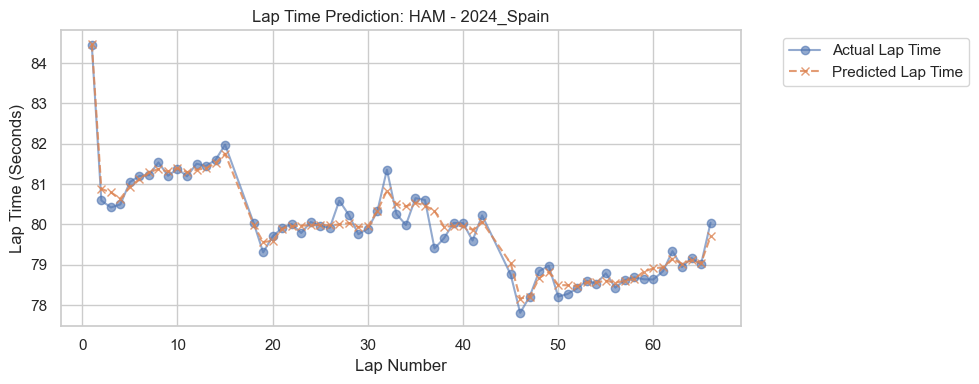

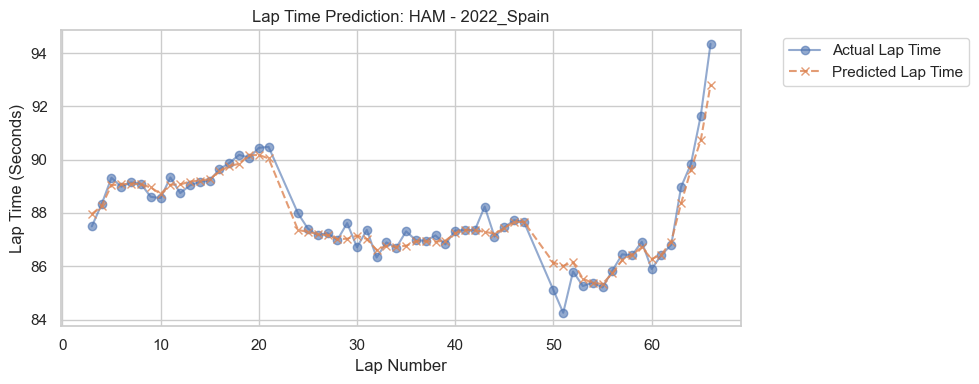

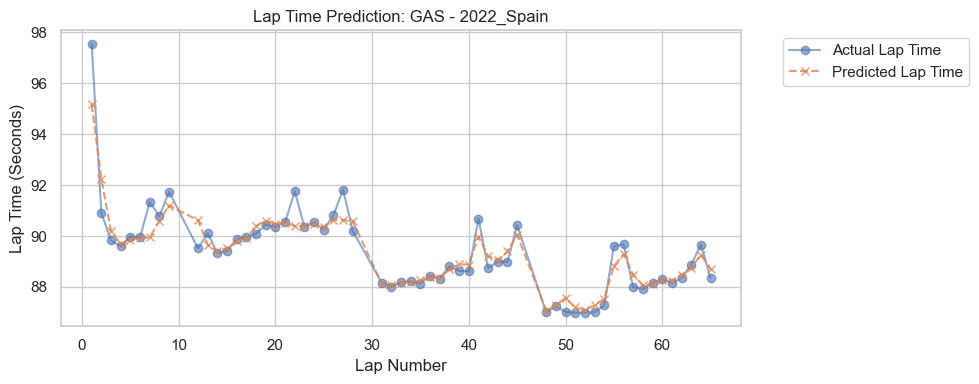

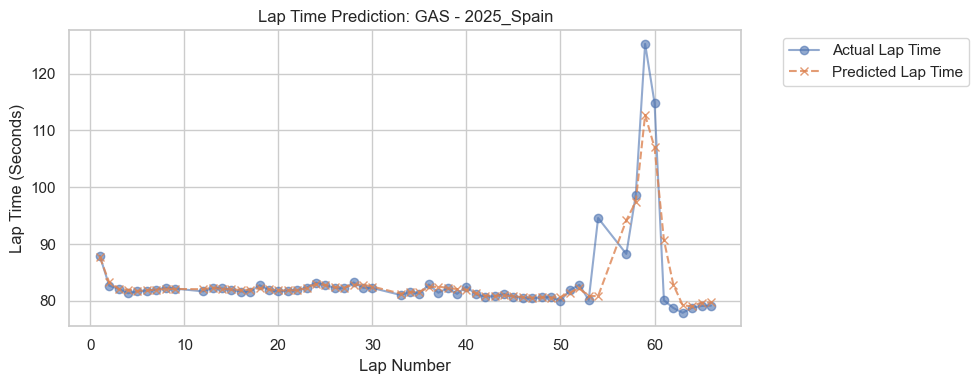

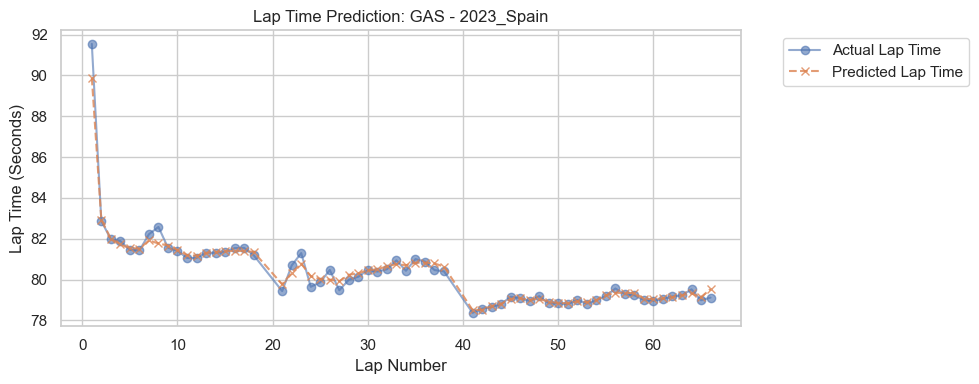

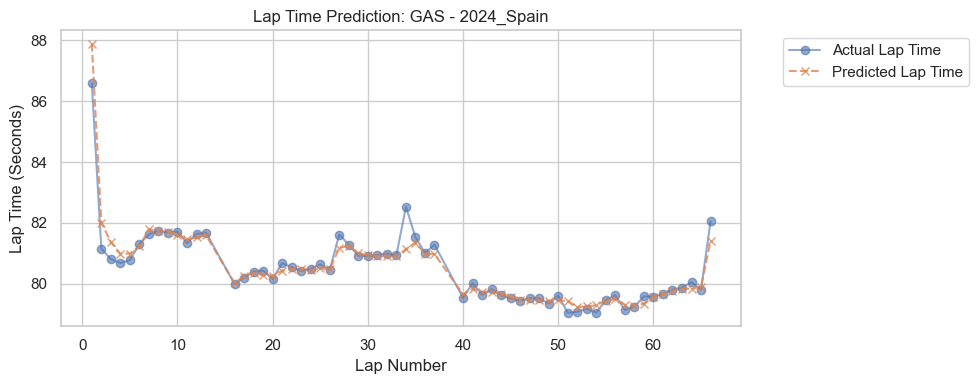

In [6]:
top_drivers = scores_df.sort_values('Laps', ascending=False)['Driver'].head(5).tolist()

for driver in top_drivers:
    df_driver = df[df['Driver'] == driver].sort_values('LapNumber')
    
    # We have multiple events for the same driver, so plotting them on separate graphs
    for event_id in df_driver['Event'].unique():
        event_name = le_event.inverse_transform([event_id])[0]
        event_df = df_driver[df_driver['Event'] == event_id]
        
        # Predict using the specific driver's model
        X_driver = event_df[features]
        predicted = models[driver].predict(X_driver)
        
        plt.figure(figsize=(10, 4))
        plt.plot(event_df['LapNumber'], event_df[target], label='Actual Lap Time', marker='o', alpha=0.6)
        plt.plot(event_df['LapNumber'], predicted, label='Predicted Lap Time', marker='x', linestyle='dashed', alpha=0.8)
        
        plt.title(f'Lap Time Prediction: {driver} - {event_name}')
        plt.xlabel('Lap Number')
        plt.ylabel('Lap Time (Seconds)')
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    print("\n" + "="*80 + "\n")
